# 01_data_collection.ipynb
# Seyma Berker | MSc Urban Spatial Science | UCL CASA 2026
# Foster + Partners industry partnership
# Run this once — data is saved to /home/jovyan/work/data/
# Cities:
#   London    — City of London administrative boundary
#   Barcelona — Eixample district
#   Singapore — Central area, 2km radius from city centre
#   Tokyo     — Shinjuku area, 800m radius
#
# Data source: OpenStreetMap contributors (2024), ODbL licence
# Accessed via: osmnx (Boeing, 2017)

In [2]:
# Install and import the libraries needed for data download

import subprocess
import sys

packages = ['osmnx', 'geopandas', 'pandas', 'matplotlib']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip',
                          'install', package, '-q'])

import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries ready.")
print(f"OSMnx version: {ox.__version__}")
print(f"GeoPandas version: {gpd.__version__}")

Libraries ready.
OSMnx version: 2.1.1
GeoPandas version: 1.1.1


In [3]:
# Download City of London street network, buildings and POIs
# I use the administrative boundary of the City of London as the study area
# The City of London is the primary pilot city for this research

print("Downloading London...")

G = ox.graph_from_place("City of London, UK", network_type="drive")
nodes, edges = ox.graph_to_gdfs(G)
edges.to_file("/home/jovyan/work/data/london_streets.gpkg", driver="GPKG")
print(f"Streets saved: {len(edges)}")

buildings = ox.features_from_place(
    "City of London, UK", tags={"building": True})
buildings.to_file("/home/jovyan/work/data/london_buildings.gpkg", driver="GPKG")
print(f"Buildings saved: {len(buildings)}")

pois = ox.features_from_place(
    "City of London, UK", tags={"amenity": True, "shop": True})
pois.to_file("/home/jovyan/work/data/london_pois.gpkg", driver="GPKG")
print(f"POIs saved: {len(pois)}")

print("London complete.")

Streets saved: 1382
Buildings saved: 2104
POIs saved: 3388
London complete.


In [4]:
# Download Singapore central area using coordinates
# I use a 2km radius from the city centre because Singapore's
# administrative boundary names did not return sufficient street data
# Coordinates: 1.3521 N, 103.8198 E (central Singapore)

print("Downloading Singapore...")

G_sgp = ox.graph_from_point(
    (1.3521, 103.8198),
    dist=2000,
    network_type="drive"
)
nodes_sgp, edges_sgp = ox.graph_to_gdfs(G_sgp)
edges_sgp.to_file(
    "/home/jovyan/work/data/singapore_streets.gpkg", driver="GPKG")
print(f"Streets saved: {len(edges_sgp)}")

buildings_sgp = ox.features_from_point(
    (1.3521, 103.8198), dist=2000, tags={"building": True})
buildings_sgp.to_file(
    "/home/jovyan/work/data/singapore_buildings.gpkg", driver="GPKG")
print(f"Buildings saved: {len(buildings_sgp)}")

pois_sgp = ox.features_from_point(
    (1.3521, 103.8198), dist=2000,
    tags={"amenity": True, "shop": True})
pois_sgp.to_file(
    "/home/jovyan/work/data/singapore_pois.gpkg", driver="GPKG")
print(f"POIs saved: {len(pois_sgp)}")

print("Singapore complete.")

Streets saved: 548
Buildings saved: 2987
POIs saved: 643
Singapore complete.


In [5]:
# Download Tokyo Shinjuku area using coordinates
# I use an 800m radius to get a comparable number of segments
# to the other cities. A larger 2km radius returned over 8,500
# segments which was too many for a fair cross-city comparison.
# Coordinates: 35.6762 N, 139.6503 E (Shinjuku, central Tokyo)

print("Downloading Tokyo...")

G_tky = ox.graph_from_point(
    (35.6762, 139.6503),
    dist=800,
    network_type="drive"
)
nodes_tky, edges_tky = ox.graph_to_gdfs(G_tky)
edges_tky.to_file(
    "/home/jovyan/work/data/tokyo_streets.gpkg", driver="GPKG")
print(f"Streets saved: {len(edges_tky)}")

buildings_tky = ox.features_from_point(
    (35.6762, 139.6503), dist=800, tags={"building": True})
buildings_tky.to_file(
    "/home/jovyan/work/data/tokyo_buildings.gpkg", driver="GPKG")
print(f"Buildings saved: {len(buildings_tky)}")

pois_tky = ox.features_from_point(
    (35.6762, 139.6503), dist=800,
    tags={"amenity": True, "shop": True})
pois_tky.to_file(
    "/home/jovyan/work/data/tokyo_pois.gpkg", driver="GPKG")
print(f"POIs saved: {len(pois_tky)}")

print("Tokyo complete.")

Streets saved: 1577
Buildings saved: 9580
POIs saved: 702
Tokyo complete.


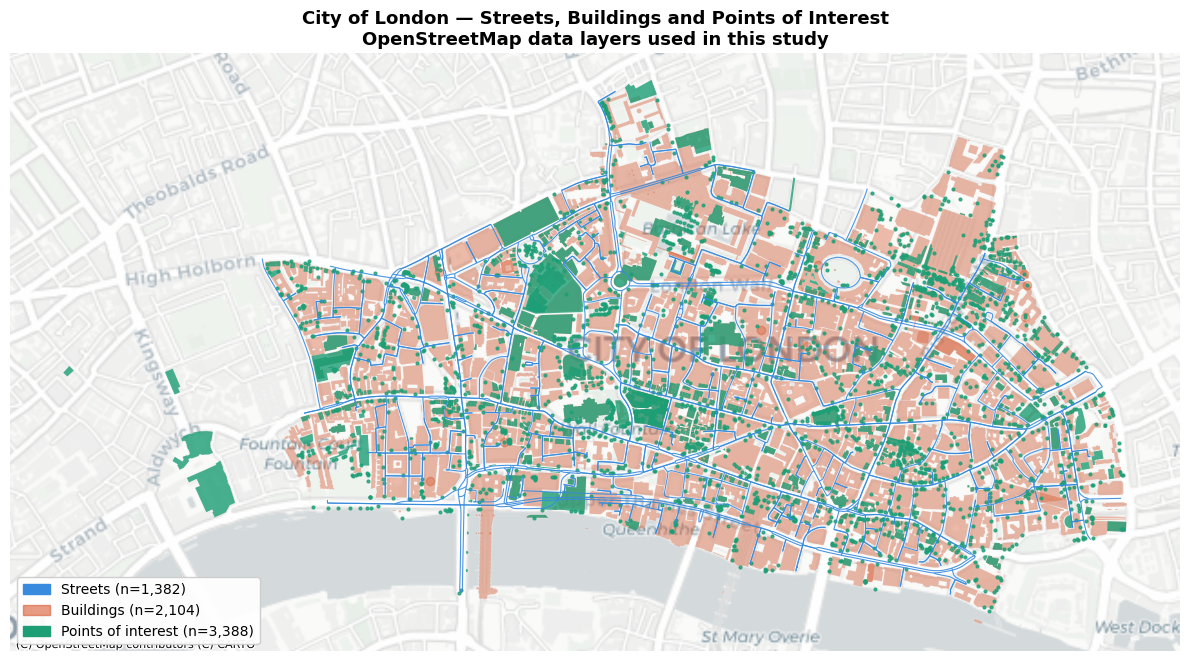

Figure 3.1 saved.


In [28]:
# Study area map showing all three data layers — Figure 3.1

import contextily as ctx
import matplotlib.patches as mpatches

edges_plot = gpd.read_file("/home/jovyan/work/data/london_streets.gpkg")
buildings_plot = gpd.read_file("/home/jovyan/work/data/london_buildings.gpkg")
pois_plot = gpd.read_file("/home/jovyan/work/data/london_pois.gpkg")

# Project to Web Mercator for basemap
edges_web = edges_plot.to_crs(epsg=3857)
buildings_web = buildings_plot.to_crs(epsg=3857)
pois_web = pois_plot.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
buildings_web.plot(ax=ax, color="#D85A30", alpha=0.4)
edges_web.plot(ax=ax, linewidth=0.8, color="#378ADD", alpha=0.9)
pois_web.plot(ax=ax, color="#1D9E75", markersize=4, alpha=0.8)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

ax.set_title("City of London — Streets, Buildings and Points of Interest\n"
             "OpenStreetMap data layers used in this study",
             fontsize=13, fontweight='bold')
ax.set_axis_off()

legend_handles = [
    mpatches.Patch(color="#378ADD", label=f"Streets (n=1,382)"),
    mpatches.Patch(color="#D85A30", alpha=0.6, label=f"Buildings (n=2,104)"),
    mpatches.Patch(color="#1D9E75", label=f"Points of interest (n=3,388)")
]
ax.legend(handles=legend_handles, loc='lower left',
          fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/london_all_data.png",
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3.1 saved.")

In [16]:
# Confirm all raw data files have been saved successfully
# These files are the input for 02_analysis.ipynb

import os

data_files = os.listdir("/home/jovyan/work/data/")
gpkg_files = sorted([f for f in data_files if f.endswith('.gpkg')])

print("Raw data files saved:")
for f in gpkg_files:
    print(f"  {f}")

print(f"\nTotal files: {len(gpkg_files)}")
print("\nData collection complete.")
print("Open 02_analysis.ipynb to run the analysis pipeline.")

Raw data files saved:
  barcelona_buildings.gpkg
  barcelona_final.gpkg
  barcelona_pois.gpkg
  barcelona_streets.gpkg
  london_buildings.gpkg
  london_pois.gpkg
  london_streets.gpkg
  singapore_buildings.gpkg
  singapore_final.gpkg
  singapore_pois.gpkg
  singapore_streets.gpkg
  tokyo_buildings.gpkg
  tokyo_final.gpkg
  tokyo_pois.gpkg
  tokyo_streets.gpkg

Total files: 15

Data collection complete.
Open 02_analysis.ipynb to run the analysis pipeline.
